In [1]:
import numpy as np
import requests
import pandas as pd
from datetime import datetime
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns


# NLP / Embedding / LLM
from sentence_transformers import SentenceTransformer
import faiss
from openai import OpenAI
import os

# Sentiment Analysis

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Godwin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:1234/v1",
    api_key="lm-studio"
)
model = "qwen3-0.6B"   

In [3]:

# ---- topic of choice----
topic = "Climate change" 


In [4]:
def get_reddit_search(keyword, total_limit=300):
    base_url = "https://www.reddit.com/search.json"
    headers = {"User-Agent": "Mozilla/5.0"}
    
    all_posts = []
    after = None
    
    while len(all_posts) < total_limit:
        remaining = total_limit - len(all_posts)
        limit = min(100, remaining)  # Reddit max allowed per call
        
        params = {
            "q": keyword,
            "limit": limit,
            "after": after
        }
        
        r = requests.get(base_url, headers=headers, params=params)
        data = r.json()["data"]
        
        children = data["children"]
        if not children:
            break  # no more results
        
        for item in children:
            d = item["data"]
            all_posts.append({
                "id": d.get("id"),
                "title": d.get("title"),
                "text": d.get("selftext"),
                "subreddit": d.get("subreddit"),
                "created_utc": datetime.utcfromtimestamp(d.get("created_utc", 0)),
                "score": d.get("score"),
                "num_comments": d.get("num_comments"),
                "url": "https://reddit.com" + d.get("permalink", "")
            })
        
        after = data.get("after")  # move to next page
        if after is None:
            break  # no more pages

    return pd.DataFrame(all_posts)


In [5]:
df = get_reddit_search(topic, 300)
print(df.head())


C:\Users\Godwin\AppData\Local\Temp\ipykernel_6812\3854931815.py:32: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  "created_utc": datetime.utcfromtimestamp(d.get("created_utc", 0)),


        id                                              title  \
0  1oje8ro  Annual climate change report finds “planet on ...   
1  1oil3rf  Bill Gates softens stance on climate change st...   
2  1m8j0wc  Does anyone else feel no one cares about clima...   
3  1mj6xwp  You're not responsible for climate change, bro...   
4  1noxnhz  CMV: people are on average in denial of how cl...   

                                                text           subreddit  \
0                                                              worldnews   
1                                                                climate   
2  Is it just me or do I feel like no one (beside...       climatechange   
3                                                     ClimateShitposting   
4  I'm not going to summarise the scientific evid...        changemyview   

          created_utc  score  num_comments  \
0 2025-10-29 19:34:46   5194           649   
1 2025-10-28 20:51:50   1083           595   
2 2025-07-24 2

In [6]:
df

,id,title,text,subreddit,created_utc,score,num_comments,url
0,1oje8ro,Annual climate change report finds “planet on ...,,worldnews,2025-10-29 19:34:46,5194,649,https://reddit.com/r/worldnews/comments/1oje8r...
1,1oil3rf,Bill Gates softens stance on climate change st...,,climate,2025-10-28 20:51:50,1083,595,https://reddit.com/r/climate/comments/1oil3rf/...
2,1m8j0wc,Does anyone else feel no one cares about clima...,Is it just me or do I feel like no one (beside...,climatechange,2025-07-24 22:59:25,2058,955,https://reddit.com/r/climatechange/comments/1m...
3,1mj6xwp,"You're not responsible for climate change, bro...",,ClimateShitposting,2025-08-06 14:58:25,2581,583,https://reddit.com/r/ClimateShitposting/commen...
4,1noxnhz,CMV: people are on average in denial of how cl...,I'm not going to summarise the scientific evid...,changemyview,2025-09-24 00:06:04,1076,429,https://reddit.com/r/changemyview/comments/1no...
...,...,...,...,...,...,...,...,...
216,zv1l9k,""" It’s getting colder and colder earlier in th...",,SelfAwarewolves,2022-12-25 16:47:13,17356,446,https://reddit.com/r/SelfAwarewolves/comments/...
217,e329iq,Boris Johnson to be replaced with melting ice ...,,worldnews,2019-11-28 18:44:22,43303,1588,https://reddit.com/r/worldnews/comments/e329iq...
218,p330h2,Climate change is making people think twice ab...,,news,2021-08-12 16:11:01,9387,1738,https://reddit.com/r/news/comments/p330h2/clim...
219,bu24qg,If we should blame anyone for the lack of acti...,Because they killed the viability of nuclear p...,unpopularopinion,2019-05-28 16:31:48,26187,3177,https://reddit.com/r/unpopularopinion/comments...


In [7]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+', '', text)           # remove URLs
    text = re.sub(r'[\r\n]+', ' ', text)          # remove line breaks
    text = re.sub(r'\s+', ' ', text)              # normalize spaces
    text = re.sub(r'[^\w\s.,!?;:()\'"-]', '', text)  # remove weird chars
    text = text.lower().strip()                     # Lowercasing to reduce vocabulary sparsity
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)
df['clean_text'].head()


0                                                     
1                                                     
2    is it just me or do i feel like no one (beside...
3                                                     
4    i'm not going to summarise the scientific evid...
Name: clean_text, dtype: object

In [8]:

df['clean_title'] = df['title'].apply(clean_text)


In [9]:
df["content"] = (
    df["clean_title"].fillna("").astype(str) + " " +
    df["clean_text"].fillna("").astype(str)
).str.strip()


In [10]:
df["content"][0]

'annual climate change report finds planet on the brink'

In [11]:
df["content"]

0      annual climate change report finds planet on t...
1      bill gates softens stance on climate change st...
2      does anyone else feel no one cares about clima...
3      you're not responsible for climate change, bro...
4      cmv: people are on average in denial of how cl...
                             ...                        
216    " its getting colder and colder earlier in the...
217    boris johnson to be replaced with melting ice ...
218    climate change is making people think twice ab...
219    if we should blame anyone for the lack of acti...
220    broadcast news networks coverage of climate ch...
Name: content, Length: 221, dtype: object

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Godwin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


sentiment_label
Negative    101
Neutral      72
Positive     48
Name: count, dtype: int64


C:\Users\Godwin\AppData\Local\Temp\ipykernel_6812\3042724375.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["sentiment_label"], palette="viridis")


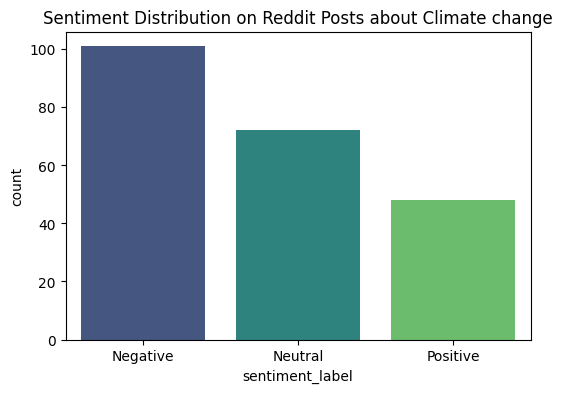

In [12]:
# ============================================
# Sentiment Analysis (VADER)
# ============================================

# Download VADER lexicon if not present
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0  # neutral for empty/missing text
    score = sia.polarity_scores(text)
    return score["compound"]

# Compute VADER compound score
df["sentiment"] = df["content"].apply(get_sentiment)

# Convert compound score → sentiment label
df["sentiment_label"] = pd.cut(
    df["sentiment"],
    bins=[-1, -0.05, 0.05, 1],
    labels=["Negative", "Neutral", "Positive"]
)

print(df["sentiment_label"].value_counts())

# Plot distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["sentiment_label"], palette="viridis")
plt.title(f"Sentiment Distribution on Reddit Posts about {topic}")
plt.show()


In [13]:
df


,id,title,text,subreddit,created_utc,score,num_comments,url,clean_text,clean_title,content,sentiment,sentiment_label
0,1oje8ro,Annual climate change report finds “planet on ...,,worldnews,2025-10-29 19:34:46,5194,649,https://reddit.com/r/worldnews/comments/1oje8r...,,annual climate change report finds planet on t...,annual climate change report finds planet on t...,0.0000,Neutral
1,1oil3rf,Bill Gates softens stance on climate change st...,,climate,2025-10-28 20:51:50,1083,595,https://reddit.com/r/climate/comments/1oil3rf/...,,bill gates softens stance on climate change st...,bill gates softens stance on climate change st...,0.0000,Neutral
2,1m8j0wc,Does anyone else feel no one cares about clima...,Is it just me or do I feel like no one (beside...,climatechange,2025-07-24 22:59:25,2058,955,https://reddit.com/r/climatechange/comments/1m...,is it just me or do i feel like no one (beside...,does anyone else feel no one cares about clima...,does anyone else feel no one cares about clima...,0.5091,Positive
3,1mj6xwp,"You're not responsible for climate change, bro...",,ClimateShitposting,2025-08-06 14:58:25,2581,583,https://reddit.com/r/ClimateShitposting/commen...,,"you're not responsible for climate change, bro...","you're not responsible for climate change, bro...",-0.2411,Negative
4,1noxnhz,CMV: people are on average in denial of how cl...,I'm not going to summarise the scientific evid...,changemyview,2025-09-24 00:06:04,1076,429,https://reddit.com/r/changemyview/comments/1no...,i'm not going to summarise the scientific evid...,cmv: people are on average in denial of how cl...,cmv: people are on average in denial of how cl...,0.9868,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,zv1l9k,""" It’s getting colder and colder earlier in th...",,SelfAwarewolves,2022-12-25 16:47:13,17356,446,https://reddit.com/r/SelfAwarewolves/comments/...,,""" its getting colder and colder earlier in the...",""" its getting colder and colder earlier in the...",0.0000,Neutral
217,e329iq,Boris Johnson to be replaced with melting ice ...,,worldnews,2019-11-28 18:44:22,43303,1588,https://reddit.com/r/worldnews/comments/e329iq...,,boris johnson to be replaced with melting ice ...,boris johnson to be replaced with melting ice ...,-0.1027,Negative
218,p330h2,Climate change is making people think twice ab...,,news,2021-08-12 16:11:01,9387,1738,https://reddit.com/r/news/comments/p330h2/clim...,,climate change is making people think twice ab...,climate change is making people think twice ab...,0.0000,Neutral
219,bu24qg,If we should blame anyone for the lack of acti...,Because they killed the viability of nuclear p...,unpopularopinion,2019-05-28 16:31:48,26187,3177,https://reddit.com/r/unpopularopinion/comments...,because they killed the viability of nuclear p...,if we should blame anyone for the lack of acti...,if we should blame anyone for the lack of acti...,-0.9830,Negative


In [14]:
# ============================================
# Text Chunking
# ============================================

def chunk_text(text, chunk_size=300, overlap=50):
    """
    Splits long text into smaller chunks.
    chunk_size = approx number of words.
    overlap = repeated words between chunks to preserve context.
    """
    words = text.split()
    chunks = []
    start = 0

    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        start = end - overlap  # move overlap backwards

    return chunks


# Create a new DataFrame of chunks
chunk_rows = []

for idx, row in df.iterrows():
    chunks = chunk_text(row["content"])
    for c in chunks:
        chunk_rows.append({
            "post_id": idx,                  # link back to original post
            "chunk_text": c,
            "sentiment_label": row["sentiment_label"]
        })

df_chunks = pd.DataFrame(chunk_rows)

print("Total chunks created:", len(df_chunks))


Total chunks created: 228


In [15]:
# ============================================
# Embedding and Vector Store (FAISS)
# ============================================

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(df_chunks["chunk_text"].tolist(), show_progress_bar=True)

# after embeddings = model.encode(...)
# normalize
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms==0] = 1.0
embeddings = embeddings / norms

# use IndexFlatIP for cosine on normalized vectors
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings.astype(np.float32))


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

In [16]:
def retrieve_similar_posts(query, top_k=20):
    q = model.encode([query])
    q = q / np.linalg.norm(q, axis=1, keepdims=True)
    distances, indices = index.search(q.astype(np.float32), top_k)
    # Get chunk rows
    selected_chunks = df_chunks.iloc[indices[0]]

    # Map back to original full posts (unique post_ids)
    post_ids = selected_chunks["post_id"].unique()

    return df.loc[post_ids][["content", "sentiment_label"]]


In [17]:
# Test retrieval
query = f"What do people think about {topic}?"
top_docs = retrieve_similar_posts(query)
top_docs

,content,sentiment_label
51,still think climate change isn't real?,Neutral
159,i hate climate change,Negative
33,at least 97 of climate scientists agree that c...,Positive
5,"what are your thoughts on climate change? hey,...",Positive
54,most people feel 'psychologically close' to cl...,Neutral
144,a once in a generation storm. whats the role o...,Neutral
205,oc how serious do eu countries think climate c...,Negative
2,does anyone else feel no one cares about clima...,Positive
84,young people feel like they have no future due...,Positive
89,more than 99.9 of studies agree: humans caused...,Positive


In [18]:
def generate_summary(query, retrieved_docs):
    context = "\n\n".join(retrieved_docs["content"].tolist())

    prompt = f"""
    Summarize the following Reddit discussions on '{query}'.
    - Provide a balanced view of opinions (positive, negative, neutral)
    - Highlight key arguments or concerns
    - Keep the summary under 200 words

    Posts:
    {context}

    Return the answer ONLY as a valid JSON object with this structure:
    {{
        "<your summary>"
    }}
    """

    response = client.chat.completions.create(
        model="Qwen3-0.6B",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.5,
        response_format={"type": "text"}  
    )

    return response.choices[0].message.content


In [19]:
from typing import Any
import json
def extract_json_from_model(content: str) -> Any:
    """Safely extract JSON from model response."""
    content = content.strip()
    if content.startswith("{") or content.startswith("["):
        try:
            return json.loads(content)
        except json.JSONDecodeError:
            pass
    match = re.search(r"```(?:json)?\s*(\{[\s\S]*\})\s*```", content)
    if match:
        try:
            return json.loads(match.group(1))
        except json.JSONDecodeError:
            pass
    match2 = re.search(r"(\{[\s\S]*\})", content)
    if match2:
        try:
            return json.loads(match2.group(1))
        except json.JSONDecodeError:
            pass
    raise ValueError("Could not parse JSON from model response.")

In [20]:
raw_output = generate_summary(query, top_docs)

In [21]:
summary = extract_json_from_model(raw_output)

In [22]:
summary

{'summary': "Reddit discussions highlight a balanced view on climate change: while over 97% of scientists agree it's happening and human-caused emissions are the main drivers, opinions vary. Many people feel psychologically close to the issue, with studies showing its impact on local communities. However, some argue skepticism grows as the word 'climate' becomes less embraced, with concerns about future consequences like extreme weather or species extinction. The debate underscores both scientific consensus and cultural shifts in public perception."}

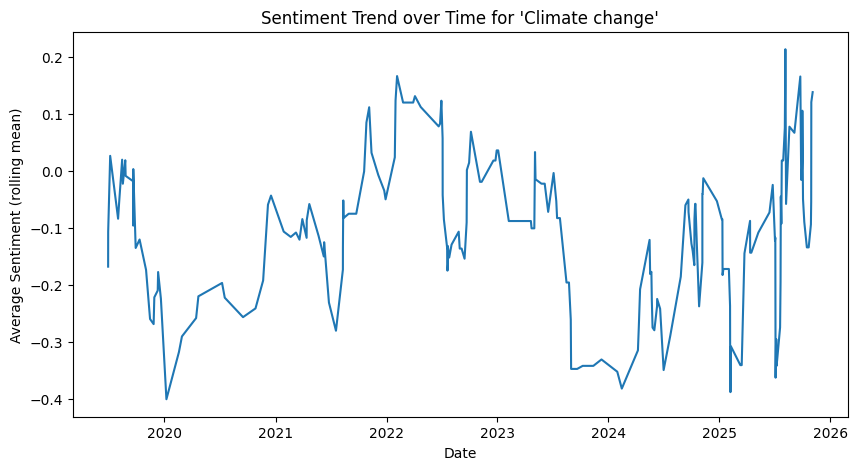

In [23]:
# ============================================
# Evaluation & Insight Visualization
# ============================================

# Sentiment over time
plt.figure(figsize=(10,5))
df_sorted = df.sort_values("created_utc")
plt.plot(df_sorted["created_utc"], df_sorted["sentiment"].rolling(10).mean())
plt.title(f"Sentiment Trend over Time for '{topic}'")
plt.xlabel("Date")
plt.ylabel("Average Sentiment (rolling mean)")
plt.show()


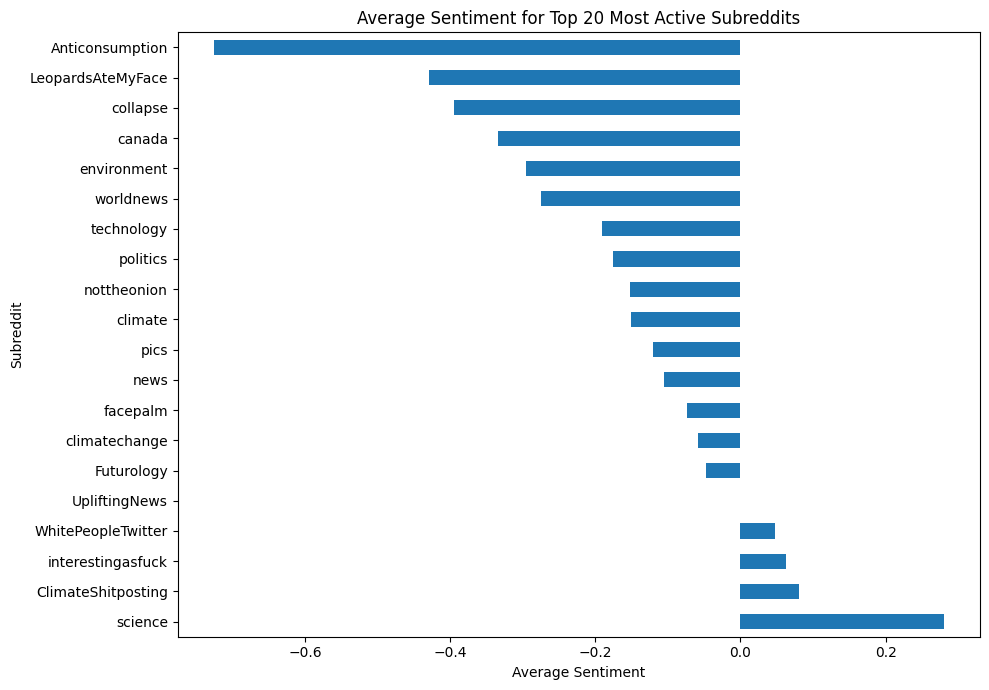

In [24]:
# ============================================
# Evaluation & Insight Visualization
# ============================================

# --- Top 20 most active subreddits ---
top_subreddits = (
    df["subreddit"]
    .value_counts()
    .head(20)
    .index
)

# Filter only those
df_top = df[df["subreddit"].isin(top_subreddits)]

# Compute average sentiment
avg_sentiment_top = (
    df_top.groupby("subreddit")["sentiment"]
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(10, 7))
avg_sentiment_top.plot(kind="barh")
plt.title("Average Sentiment for Top 20 Most Active Subreddits")
plt.xlabel("Average Sentiment")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()



In [25]:
# ============================================
# Save Outputs
# ============================================

df.to_csv(f"reddit_{topic.replace(' ', '_')}_data.csv", index=False)
with open(f"summary_{topic.replace(' ', '_')}.txt", "w", encoding="utf-8") as f:
    f.write(summary["summary"])

print("Data and summary saved successfully.")


Data and summary saved successfully.


In [26]:
summary["summary"]

"Reddit discussions highlight a balanced view on climate change: while over 97% of scientists agree it's happening and human-caused emissions are the main drivers, opinions vary. Many people feel psychologically close to the issue, with studies showing its impact on local communities. However, some argue skepticism grows as the word 'climate' becomes less embraced, with concerns about future consequences like extreme weather or species extinction. The debate underscores both scientific consensus and cultural shifts in public perception."